<a href="https://colab.research.google.com/github/sakshi703gupta-source/BCI-Internship/blob/main/CNN_BiLSTM_BiGRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import scipy.io as sio

from google.colab import drive
drive.mount('/content/drive')

mci_mat = sio.loadmat('/content/drive/MyDrive/MCI.mat')
normal_mat = sio.loadmat('/content/drive/MyDrive/normal.mat')

print("MCI keys:")
for k, v in mci_mat.items():
    if not k.startswith('__'):
        print(f"  '{k}': shape={np.array(v).shape}, dtype={np.array(v).dtype}")

print("\nNormal keys:")
for k, v in normal_mat.items():
    if not k.startswith('__'):
        print(f"  '{k}': shape={np.array(v).shape}, dtype={np.array(v).dtype}")

Mounted at /content/drive
MCI keys:
  'MCI': shape=(1, 7), dtype=[('epoch', 'O'), ('odor', 'O'), ('noisy', 'O')]

Normal keys:
  'normal': shape=(1, 15), dtype=[('epoch', 'O'), ('odor', 'O'), ('noisy', 'O')]


In [3]:
import numpy as np
import scipy.io as sio

mci_mat = sio.loadmat('/content/drive/MyDrive/MCI.mat', simplify_cells=True)
normal_mat = sio.loadmat('/content/drive/MyDrive/normal.mat', simplify_cells=True)

mci_data = mci_mat['MCI']
normal_data = normal_mat['normal']

print("MCI subject 0:")
print(f"  epoch shape : {np.array(mci_data[0]['epoch']).shape}")
print(f"  odor values : {np.unique(np.array(mci_data[0]['odor']))}")
print(f"  noisy values: {np.unique(np.array(mci_data[0]['noisy']))}")

print("\nNormal subject 0:")
print(f"  epoch shape : {np.array(normal_data[0]['epoch']).shape}")
print(f"  odor values : {np.unique(np.array(normal_data[0]['odor']))}")
print(f"  noisy values: {np.unique(np.array(normal_data[0]['noisy']))}")

MCI subject 0:
  epoch shape : (4, 600, 120)
  odor values : [0 1]
  noisy values: []

Normal subject 0:
  epoch shape : (4, 600, 119)
  odor values : [0 1]
  noisy values: [  0  10  14  18  19  20  23  25  32  33  35  40  41  42  43  45  46  47
  48  49  52  53  54  56  57  58  59  60  61  62  64  66  67  68  69  78
  79  82  83 107 110 111 112 113 117 119]


In [4]:
import numpy as np
import scipy.io as sio

mci_mat = sio.loadmat('/content/drive/MyDrive/MCI.mat', simplify_cells=True)
normal_mat = sio.loadmat('/content/drive/MyDrive/normal.mat', simplify_cells=True)

mci_data = mci_mat['MCI']
normal_data = normal_mat['normal']

def load_subject(subject, label, subject_id):
    epoch = np.array(subject['epoch'])   # shape: (4, 600, n_trials)
    noisy = np.array(subject['noisy'])   # noisy trial indices

    n_trials = epoch.shape[2]
    all_indices = np.arange(n_trials)

    if noisy.ndim == 0 or len(noisy) == 0:
        clean_indices = all_indices
    else:
        noisy = noisy.astype(int)
        clean_indices = np.setdiff1d(all_indices, noisy)

    epoch_clean = epoch[:, :, clean_indices]  # (4, 600, n_clean)
    n_clean = epoch_clean.shape[2]

    # transpose to (n_trials, 600, 4) as the model expects (T x C)
    epoch_clean = epoch_clean.transpose(2, 1, 0)  # (n_clean, 600, 4)

    # per-epoch per-channel z-score normalization (as stated in paper)
    mean = epoch_clean.mean(axis=1, keepdims=True)  # (n_clean, 1, 4)
    std  = epoch_clean.std(axis=1, keepdims=True)
    std[std == 0] = 1e-8
    epoch_clean = (epoch_clean - mean) / std

    labels     = np.full(n_clean, label, dtype=np.int32)
    subject_ids = np.full(n_clean, subject_id, dtype=np.int32)

    return epoch_clean, labels, subject_ids


all_epochs = []
all_labels = []
all_subject_ids = []

# MCI subjects → label 1
for i, subj in enumerate(mci_data):
    ep, lb, sid = load_subject(subj, label=1, subject_id=i)
    all_epochs.append(ep)
    all_labels.append(lb)
    all_subject_ids.append(sid)
    print(f"MCI subject {i}: {ep.shape[0]} clean trials")

# HC subjects → label 0, subject_id continues after MCI
n_mci = len(mci_data)
for i, subj in enumerate(normal_data):
    ep, lb, sid = load_subject(subj, label=0, subject_id=n_mci + i)
    all_epochs.append(ep)
    all_labels.append(lb)
    all_subject_ids.append(sid)
    print(f"HC subject {i}: {ep.shape[0]} clean trials")

X = np.concatenate(all_epochs,      axis=0)  # (total_trials, 600, 4)
y = np.concatenate(all_labels,      axis=0)  # (total_trials,)
groups = np.concatenate(all_subject_ids, axis=0)  # (total_trials,)

print(f"\nFinal X shape    : {X.shape}")
print(f"Final y shape    : {y.shape}")
print(f"Label distribution: HC={np.sum(y==0)}, MCI={np.sum(y==1)}")
print(f"Unique subjects  : {np.unique(groups)}")
print(f"Total subjects   : {len(np.unique(groups))}")

MCI subject 0: 120 clean trials
MCI subject 1: 121 clean trials
MCI subject 2: 121 clean trials
MCI subject 3: 121 clean trials
MCI subject 4: 118 clean trials
MCI subject 5: 115 clean trials
MCI subject 6: 117 clean trials
HC subject 0: 74 clean trials
HC subject 1: 117 clean trials
HC subject 2: 121 clean trials
HC subject 3: 117 clean trials
HC subject 4: 106 clean trials
HC subject 5: 111 clean trials
HC subject 6: 38 clean trials
HC subject 7: 98 clean trials
HC subject 8: 110 clean trials
HC subject 9: 110 clean trials
HC subject 10: 88 clean trials
HC subject 11: 69 clean trials
HC subject 12: 102 clean trials
HC subject 13: 114 clean trials
HC subject 14: 116 clean trials

Final X shape    : (2324, 600, 4)
Final y shape    : (2324,)
Label distribution: HC=1491, MCI=833
Unique subjects  : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Total subjects   : 22


In [6]:
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

# with only 22 subjects, we need to split at subject level first
# then map back to trial indices

subject_ids_unique = np.unique(groups)
subject_labels = np.array([y[groups == s][0] for s in subject_ids_unique])

print("Subject-level label distribution:")
print(f"  HC subjects : {np.sum(subject_labels==0)}")
print(f"  MCI subjects: {np.sum(subject_labels==1)}")

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

folds = []
for fold_idx, (trainval_subj_idx, test_subj_idx) in enumerate(
        sgkf.split(subject_ids_unique, subject_labels, subject_ids_unique)):

    test_subjects   = subject_ids_unique[test_subj_idx]
    trainval_subjects = subject_ids_unique[trainval_subj_idx]
    trainval_subj_labels = subject_labels[trainval_subj_idx]

    test_mask     = np.isin(groups, test_subjects)
    trainval_mask = np.isin(groups, trainval_subjects)

    X_test     = X[test_mask]
    y_test     = y[test_mask]
    X_trainval = X[trainval_mask]
    y_trainval = y[trainval_mask]
    g_trainval = groups[trainval_mask]

    # inner split on subjects for validation
    inner_sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
    train_inner_idx, val_inner_idx = next(
        inner_sgkf.split(trainval_subjects, trainval_subj_labels, trainval_subjects))

    train_subjects = trainval_subjects[train_inner_idx]
    val_subjects   = trainval_subjects[val_inner_idx]

    train_mask = np.isin(g_trainval, train_subjects)
    val_mask   = np.isin(g_trainval, val_subjects)

    X_train = X_trainval[train_mask]
    y_train = y_trainval[train_mask]
    X_val   = X_trainval[val_mask]
    y_val   = y_trainval[val_mask]

    folds.append({
        'X_train': X_train, 'y_train': y_train,
        'X_val'  : X_val,   'y_val'  : y_val,
        'X_test' : X_test,  'y_test' : y_test,
    })

    print(f"Fold {fold_idx+1}:")
    print(f"  Train : {X_train.shape}, HC={np.sum(y_train==0)}, MCI={np.sum(y_train==1)}")
    print(f"  Val   : {X_val.shape},   HC={np.sum(y_val==0)},   MCI={np.sum(y_val==1)}")
    print(f"  Test  : {X_test.shape},  HC={np.sum(y_test==0)},  MCI={np.sum(y_test==1)}")
    print()

Subject-level label distribution:
  HC subjects : 15
  MCI subjects: 7
Fold 1:
  Train : (1287, 600, 4), HC=927, MCI=360
  Val   : (457, 600, 4),   HC=221,   MCI=236
  Test  : (580, 600, 4),  HC=343,  MCI=237

Fold 2:
  Train : (1345, 600, 4), HC=868, MCI=477
  Val   : (535, 600, 4),   HC=415,   MCI=120
  Test  : (444, 600, 4),  HC=208,  MCI=236

Fold 3:
  Train : (1387, 600, 4), HC=913, MCI=474
  Val   : (573, 600, 4),   HC=335,   MCI=238
  Test  : (364, 600, 4),  HC=243,  MCI=121

Fold 4:
  Train : (1449, 600, 4), HC=975, MCI=474
  Val   : (500, 600, 4),   HC=262,   MCI=238
  Test  : (375, 600, 4),  HC=254,  MCI=121

Fold 5:
  Train : (1333, 600, 4), HC=854, MCI=479
  Val   : (430, 600, 4),   HC=194,   MCI=236
  Test  : (561, 600, 4),  HC=443,  MCI=118



In [7]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K

def se_block(x, reduction_ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(filters // reduction_ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, filters))(se)
    return layers.Multiply()([x, se])

def residual_block(x, filters, kernel_size=3):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv1D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

def build_model(input_shape=(600, 4)):
    inputs = layers.Input(shape=input_shape)

    # CNN Block 1: 64 filters
    x = layers.Conv1D(64, kernel_size=3, strides=1, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = se_block(x, reduction_ratio=16)
    x = residual_block(x, filters=64, kernel_size=3)
    x = layers.Dropout(0.35)(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # CNN Block 2: 128 filters
    x = layers.Conv1D(128, kernel_size=3, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = se_block(x, reduction_ratio=16)
    x = residual_block(x, filters=128, kernel_size=3)
    x = layers.Dropout(0.35)(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # pre-RNN dropout
    x = layers.Dropout(0.35)(x)

    # BiLSTM with layer normalization
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.LayerNormalization()(x)

    # BiGRU
    x = layers.Bidirectional(layers.GRU(64, return_sequences=False))(x)
    x = layers.Dropout(0.35)(x)

    # Dense classification head
    x = layers.Dense(160, activation='relu')(x)
    x = layers.Dropout(0.35)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model

model = build_model(input_shape=(600, 4))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 600, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 600, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 600, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 600, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        320 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 600, 64)   │          0 │ re_lu[0][0],      │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 600, 64)   │     12,352 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 600, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 600, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 600, 64)   │     12,352 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 600, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 600, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 600, 64)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 600, 64)   │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 300, 64)   │          0 │ dropout[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 300, 128)  │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 561,997 (2.14 MB)

 Trainable params: 560,845 (2.14 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [8]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

def label_smoothing_loss(y_true, y_pred, smoothing=0.05):
    y_true = tf.cast(y_true, tf.float32)
    y_true_smooth = y_true * (1 - smoothing) + 0.5 * smoothing
    bce = tf.keras.losses.binary_crossentropy(y_true_smooth, y_pred)
    return bce

all_fold_results = []

for fold_idx, fold in enumerate(folds):
    print(f"\n{'='*50}")
    print(f"FOLD {fold_idx + 1} / 5")
    print(f"{'='*50}")

    X_train = fold['X_train']
    y_train = fold['y_train']
    X_val   = fold['X_val']
    y_val   = fold['y_val']
    X_test  = fold['X_test']
    y_test  = fold['y_test']

    # class weights computed from training fold only (paper section 2.3.5)
    classes = np.array([0, 1])
    cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weight_dict = {0: cw[0], 1: cw[1]}
    print(f"Class weights: HC={cw[0]:.3f}, MCI={cw[1]:.3f}")

    # build fresh model for each fold
    tf.random.set_seed(42)
    model = build_model(input_shape=(600, 4))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=label_smoothing_loss,
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            verbose=1
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=120,
        batch_size=16,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

    # save model and history for this fold
    model.save(f'/content/drive/MyDrive/fold_{fold_idx+1}_model.keras')

    all_fold_results.append({
        'model'  : model,
        'history': history,
        'fold'   : fold_idx + 1
    })

    print(f"\nFold {fold_idx+1} training complete.")
    val_loss_min = min(history.history['val_loss'])
    print(f"Best val_loss: {val_loss_min:.4f}")


FOLD 1 / 5
Class weights: HC=0.694, MCI=1.788
Epoch 1/120
81/81 ━━━━━━━━━━━━━━━━━━━━ 52s 490ms/step - accuracy: 0.8260 - loss: 0.4248 - val_accuracy: 0.4836 - val_loss: 2.2227 - learning_rate: 0.0010
Epoch 2/120
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 457ms/step - accuracy: 0.9697 - loss: 0.2069 - val_accuracy: 0.4836 - val_loss: 1.7755 - learning_rate: 0.0010
Epoch 3/120
81/81 ━━━━━━━━━━━━━━━━━━━━ 42s 468ms/step - accuracy: 0.9876 - loss: 0.1658 - val_accuracy: 0.4836 - val_loss: 1.5239 - learning_rate: 0.0010
Epoch 4/120
81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 453ms/step - accuracy: 0.9907 - loss: 0.1496 - val_accuracy: 0.9628 - val_loss: 0.1941 - learning_rate: 0.0010
Epoch 5/120
81/81 ━━━━━━━━━━━━━━━━━━━━ 38s 468ms/step - accuracy: 0.9883 - loss: 0.1446 - val_accuracy: 0.6761 - val_loss: 0.9748 - learning_rate: 0.0010
Epoch 6/120
81/81 ━━━━━━━━━━━━━━━━━━━━ 38s 468ms/step - accuracy: 0.9852 - loss: 0.1594 - val_accuracy: 0.9737 - val_loss: 0.1887 - learning_rate: 0.0010
Epoch 7/120
81/81 ━━━━━━━━━━━

In [11]:
import numpy as np
import tensorflow as tf
from scipy.special import expit
from scipy.optimize import minimize_scalar
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix)

# reload saved models from drive
loaded_models = []
for i in range(1, 6):
    path = f'/content/drive/MyDrive/fold_{i}_model.keras'
    m = tf.keras.models.load_model(
        path,
        custom_objects={'label_smoothing_loss': label_smoothing_loss}
    )
    loaded_models.append(m)
    print(f"Loaded fold {i} model")

def get_logits(model, X):
    probs = model.predict(X, batch_size=16, verbose=0).flatten()
    probs = np.clip(probs, 1e-7, 1 - 1e-7)
    logits = np.log(probs / (1 - probs))
    return logits

def temperature_scale(logits, T):
    return expit(logits / T)

def find_temperature(logits, y_true):
    def nll_loss(T):
        probs = temperature_scale(logits, T)
        probs = np.clip(probs, 1e-7, 1 - 1e-7)
        loss  = -np.mean(y_true * np.log(probs) + (1 - y_true) * np.log(1 - probs))
        return loss
    result = minimize_scalar(nll_loss, bounds=(0.01, 10.0), method='bounded')
    return result.x

def youden_threshold(probs, y_true):
    thresholds = np.linspace(0.01, 0.99, 200)
    best_j, best_thresh = -1, 0.5
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0,1]).ravel()
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        j = sens + spec - 1
        if j > best_j:
            best_j = j
            best_thresh = t
    return best_thresh

def evaluate_at_threshold(probs, y_true, threshold):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0,1]).ravel()
    return {
        'accuracy'         : accuracy_score(y_true, preds),
        'balanced_accuracy': balanced_accuracy_score(y_true, preds),
        'sensitivity'      : tp / (tp + fn + 1e-8),
        'specificity'      : tn / (tn + fp + 1e-8),
        'precision'        : precision_score(y_true, preds, zero_division=0),
        'f1'               : f1_score(y_true, preds, zero_division=0),
        'roc_auc'          : roc_auc_score(y_true, probs),
        'pr_auc'           : average_precision_score(y_true, probs),
        'threshold'        : threshold,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }

fold_metrics_youden = []
fold_metrics_035    = []
fold_metrics_050    = []
fold_temperatures   = []
fold_thresholds     = []
fold_test_probs     = []
fold_test_labels    = []

for fold_idx in range(5):
    print(f"\nFold {fold_idx+1}")

    model  = loaded_models[fold_idx]
    fold   = folds[fold_idx]
    X_val  = fold['X_val']
    y_val  = fold['y_val']
    X_test = fold['X_test']
    y_test = fold['y_test']

    print(f"  Val  size: {X_val.shape}, HC={np.sum(y_val==0)}, MCI={np.sum(y_val==1)}")
    print(f"  Test size: {X_test.shape}, HC={np.sum(y_test==0)}, MCI={np.sum(y_test==1)}")

    val_logits    = get_logits(model, X_val)
    T             = find_temperature(val_logits, y_val)
    val_probs_cal = temperature_scale(val_logits, T)
    thresh_youden = youden_threshold(val_probs_cal, y_val)

    fold_temperatures.append(T)
    fold_thresholds.append(thresh_youden)
    print(f"  Temperature T    = {T:.4f}")
    print(f"  Youden threshold = {thresh_youden:.4f}")

    test_logits    = get_logits(model, X_test)
    test_probs_cal = temperature_scale(test_logits, T)

    fold_test_probs.append(test_probs_cal)
    fold_test_labels.append(y_test)

    m_youden = evaluate_at_threshold(test_probs_cal, y_test, thresh_youden)
    m_035    = evaluate_at_threshold(test_probs_cal, y_test, 0.35)
    m_050    = evaluate_at_threshold(test_probs_cal, y_test, 0.50)

    fold_metrics_youden.append(m_youden)
    fold_metrics_035.append(m_035)
    fold_metrics_050.append(m_050)

    print(f"  [Youden] Acc={m_youden['accuracy']:.4f}, "
          f"Sens={m_youden['sensitivity']:.4f}, "
          f"Spec={m_youden['specificity']:.4f}, "
          f"ROC-AUC={m_youden['roc_auc']:.4f}, "
          f"PR-AUC={m_youden['pr_auc']:.4f}")
    print(f"  [0.35]   Acc={m_035['accuracy']:.4f}, "
          f"Sens={m_035['sensitivity']:.4f}, "
          f"Spec={m_035['specificity']:.4f}")
    print(f"  [0.50]   Acc={m_050['accuracy']:.4f}, "
          f"Sens={m_050['sensitivity']:.4f}, "
          f"Spec={m_050['specificity']:.4f}")

print(f"\n{'='*60}")
print("FINAL RESULTS (mean ± std across 5 folds)")
print(f"{'='*60}")

def summarize(metrics_list, label):
    keys = ['accuracy','balanced_accuracy','sensitivity','specificity',
            'precision','f1','roc_auc','pr_auc']
    print(f"\n--- {label} ---")
    for k in keys:
        vals = [m[k] for m in metrics_list]
        print(f"  {k:20s}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")

summarize(fold_metrics_youden, "Youden threshold")
summarize(fold_metrics_035,    "Fixed threshold 0.35")
summarize(fold_metrics_050,    "Fixed threshold 0.50")

print(f"\n  Temperature T : {np.mean(fold_temperatures):.3f} ± {np.std(fold_temperatures):.3f}")
print(f"  Youden thresh : {np.mean(fold_thresholds):.3f} ± {np.std(fold_thresholds):.3f}")

Loaded fold 1 model
Loaded fold 2 model
Loaded fold 3 model
Loaded fold 4 model
Loaded fold 5 model

Fold 1
  Val  size: (457, 600, 4), HC=221, MCI=236
  Test size: (580, 600, 4), HC=343, MCI=237
  Temperature T    = 0.6246
  Youden threshold = 0.0248
  [Youden] Acc=0.9966, Sens=0.9958, Spec=0.9971, ROC-AUC=0.9999, PR-AUC=0.9998
  [0.35]   Acc=0.9966, Sens=0.9916, Spec=1.0000
  [0.50]   Acc=0.9966, Sens=0.9916, Spec=1.0000

Fold 2
  Val  size: (535, 600, 4), HC=415, MCI=120
  Test size: (444, 600, 4), HC=208, MCI=236
  Temperature T    = 0.5698
  Youden threshold = 0.0494
  [Youden] Acc=0.9730, Sens=0.9661, Spec=0.9808, ROC-AUC=0.9972, PR-AUC=0.9977
  [0.35]   Acc=0.9730, Sens=0.9534, Spec=0.9952
  [0.50]   Acc=0.9730, Sens=0.9534, Spec=0.9952

Fold 3
  Val  size: (573, 600, 4), HC=335, MCI=238
  Test size: (364, 600, 4), HC=243, MCI=121
  Temperature T    = 0.5611
  Youden threshold = 0.0888
  [Youden] Acc=0.9918, Sens=0.9752, Spec=1.0000, ROC-AUC=0.9990, PR-AUC=0.9982
  [0.35]   Acc=

Pooled confusion matrix: TN=1321, FP=170, FN=14, TP=819
Pooled sensitivity: 0.9832
Pooled specificity: 0.8860


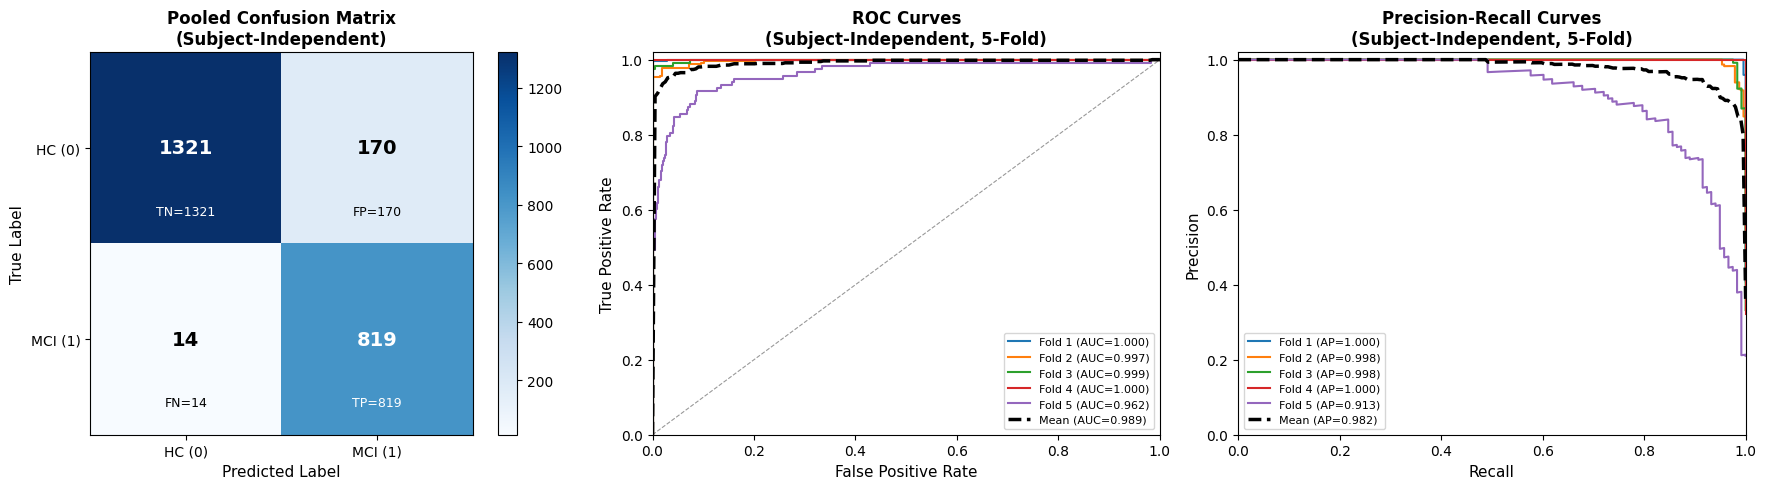

Saved to Drive.


In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import (confusion_matrix, roc_curve, precision_recall_curve,
                              auc, average_precision_score)

pool_y_true  = np.concatenate(fold_test_labels)
pool_y_probs = np.concatenate(fold_test_probs)

# pooled Youden threshold (mean across folds as paper uses fold-specific,
# for pooled confusion matrix we use 0.5 as a neutral point like the paper fig)
pool_preds = (pool_y_probs >= np.mean(fold_thresholds)).astype(int)
cm = confusion_matrix(pool_y_true, pool_preds, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(f"Pooled confusion matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Pooled sensitivity: {tp/(tp+fn):.4f}")
print(f"Pooled specificity: {tn/(tn+fp):.4f}")

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# --- Plot 1: Pooled Confusion Matrix ---
ax1 = fig.add_subplot(gs[0])
im  = ax1.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax1)
ax1.set_title('Pooled Confusion Matrix\n(Subject-Independent)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=11)
ax1.set_ylabel('True Label',      fontsize=11)
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['HC (0)', 'MCI (1)'])
ax1.set_yticklabels(['HC (0)', 'MCI (1)'])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black',
                 fontsize=14, fontweight='bold')
# add TN/FP/FN/TP labels
ax1.text(0, 0.35, f'TN={tn}', ha='center', color='white' if cm[0,0]>cm.max()/2 else 'black', fontsize=9)
ax1.text(1, 0.35, f'FP={fp}', ha='center', color='white' if cm[0,1]>cm.max()/2 else 'black', fontsize=9)
ax1.text(0, 1.35, f'FN={fn}', ha='center', color='white' if cm[1,0]>cm.max()/2 else 'black', fontsize=9)
ax1.text(1, 1.35, f'TP={tp}', ha='center', color='white' if cm[1,1]>cm.max()/2 else 'black', fontsize=9)

# --- Plot 2: ROC curves per fold ---
ax2   = fig.add_subplot(gs[1])
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
mean_fpr = np.linspace(0, 1, 200)
tprs     = []

for i, (y_true, y_probs) in enumerate(zip(fold_test_labels, fold_test_probs)):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    fold_auc    = auc(fpr, tpr)
    interp_tpr  = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    ax2.plot(fpr, tpr, color=colors[i], lw=1.5,
             label=f'Fold {i+1} (AUC={fold_auc:.3f})')

mean_tpr    = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc    = auc(mean_fpr, mean_tpr)
ax2.plot(mean_fpr, mean_tpr, color='black', lw=2.5, linestyle='--',
         label=f'Mean (AUC={mean_auc:.3f})')
ax2.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.4)
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate',  fontsize=11)
ax2.set_title('ROC Curves\n(Subject-Independent, 5-Fold)', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=8)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

# --- Plot 3: Precision-Recall curves per fold ---
ax3 = fig.add_subplot(gs[2])
mean_recall = np.linspace(0, 1, 200)
precisions  = []

for i, (y_true, y_probs) in enumerate(zip(fold_test_labels, fold_test_probs)):
    prec, rec, _ = precision_recall_curve(y_true, y_probs)
    fold_prauc   = average_precision_score(y_true, y_probs)
    interp_prec  = np.interp(mean_recall, rec[::-1], prec[::-1])
    precisions.append(interp_prec)
    ax3.plot(rec, prec, color=colors[i], lw=1.5,
             label=f'Fold {i+1} (AP={fold_prauc:.3f})')

mean_prec = np.mean(precisions, axis=0)
mean_ap   = np.mean([average_precision_score(y_t, y_p)
                     for y_t, y_p in zip(fold_test_labels, fold_test_probs)])
ax3.plot(mean_recall, mean_prec, color='black', lw=2.5, linestyle='--',
         label=f'Mean (AP={mean_ap:.3f})')
ax3.set_xlabel('Recall',    fontsize=11)
ax3.set_ylabel('Precision', fontsize=11)
ax3.set_title('Precision-Recall Curves\n(Subject-Independent, 5-Fold)', fontsize=12, fontweight='bold')
ax3.legend(loc='lower left', fontsize=8)
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive.")

In [14]:
# check the actual dense layer names in loaded_models[0]
for layer in loaded_models[0].layers:
    print(layer.name, layer.output.shape)

input_layer_1 (None, 600, 4)
conv1d_6 (None, 600, 64)
batch_normalization_6 (None, 600, 64)
re_lu_6 (None, 600, 64)
global_average_pooling1d_2 (None, 64)
dense_6 (None, 4)
dense_7 (None, 64)
reshape_2 (None, 1, 64)
multiply_2 (None, 600, 64)
conv1d_7 (None, 600, 64)
batch_normalization_7 (None, 600, 64)
re_lu_7 (None, 600, 64)
conv1d_8 (None, 600, 64)
batch_normalization_8 (None, 600, 64)
add_2 (None, 600, 64)
re_lu_8 (None, 600, 64)
dropout_5 (None, 600, 64)
max_pooling1d_2 (None, 300, 64)
conv1d_9 (None, 300, 128)
batch_normalization_9 (None, 300, 128)
re_lu_9 (None, 300, 128)
global_average_pooling1d_3 (None, 128)
dense_8 (None, 8)
dense_9 (None, 128)
reshape_3 (None, 1, 128)
multiply_3 (None, 300, 128)
conv1d_10 (None, 300, 128)
batch_normalization_10 (None, 300, 128)
re_lu_10 (None, 300, 128)
conv1d_11 (None, 300, 128)
batch_normalization_11 (None, 300, 128)
add_3 (None, 300, 128)
re_lu_11 (None, 300, 128)
dropout_6 (None, 300, 128)
max_pooling1d_3 (None, 150, 128)
dropout_7 (None

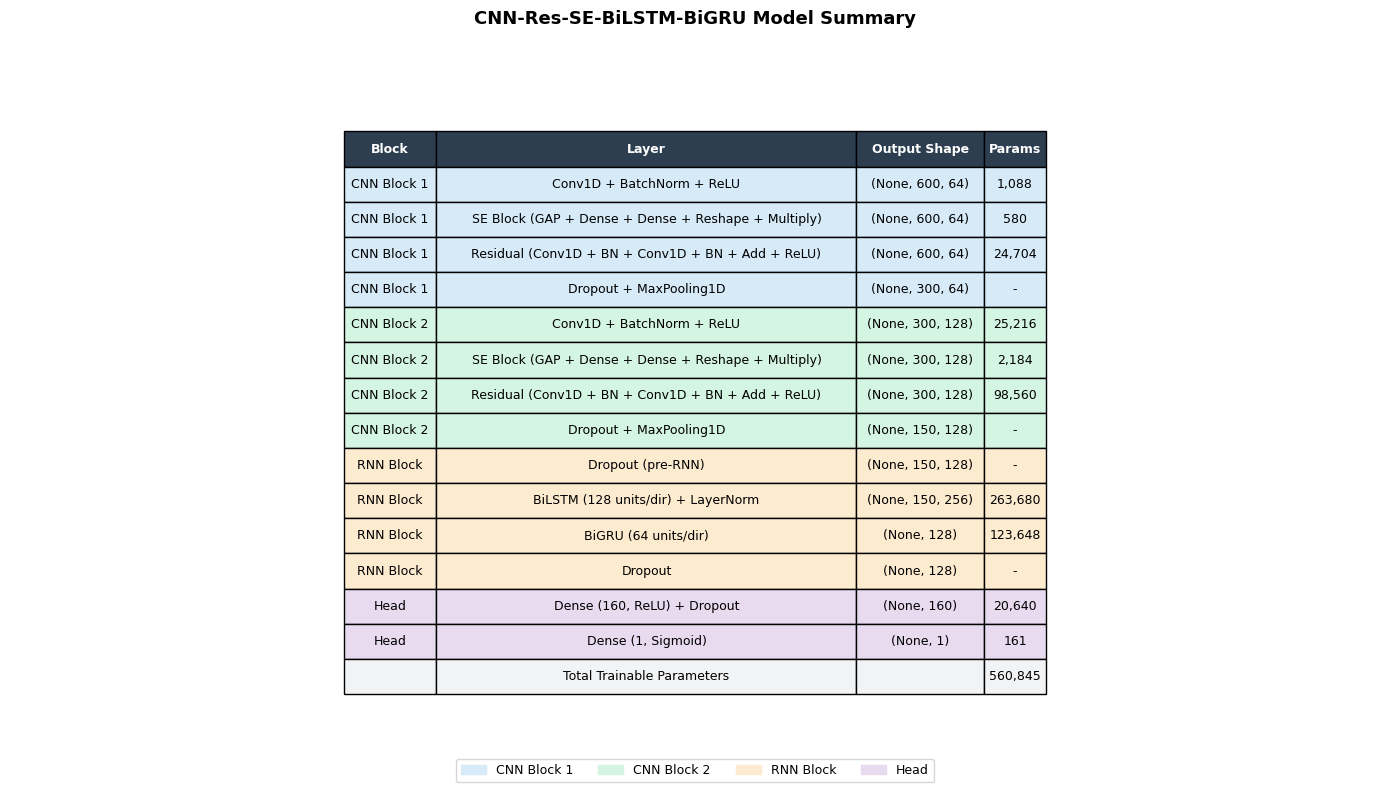

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

layers = [
    # Block, Layer name, Output Shape, Params
    ("CNN Block 1", "Conv1D + BatchNorm + ReLU", "(None, 600, 64)", "1,088"),
    ("CNN Block 1", "SE Block (GAP + Dense + Dense + Reshape + Multiply)", "(None, 600, 64)", "580"),
    ("CNN Block 1", "Residual (Conv1D + BN + Conv1D + BN + Add + ReLU)", "(None, 600, 64)", "24,704"),
    ("CNN Block 1", "Dropout + MaxPooling1D", "(None, 300, 64)", "-"),
    ("CNN Block 2", "Conv1D + BatchNorm + ReLU", "(None, 300, 128)", "25,216"),
    ("CNN Block 2", "SE Block (GAP + Dense + Dense + Reshape + Multiply)", "(None, 300, 128)", "2,184"),
    ("CNN Block 2", "Residual (Conv1D + BN + Conv1D + BN + Add + ReLU)", "(None, 300, 128)", "98,560"),
    ("CNN Block 2", "Dropout + MaxPooling1D", "(None, 150, 128)", "-"),
    ("RNN Block",   "Dropout (pre-RNN)", "(None, 150, 128)", "-"),
    ("RNN Block",   "BiLSTM (128 units/dir) + LayerNorm", "(None, 150, 256)", "263,680"),
    ("RNN Block",   "BiGRU (64 units/dir)", "(None, 128)", "123,648"),
    ("RNN Block",   "Dropout", "(None, 128)", "-"),
    ("Head",        "Dense (160, ReLU) + Dropout", "(None, 160)", "20,640"),
    ("Head",        "Dense (1, Sigmoid)", "(None, 1)", "161"),
]

block_colors = {
    "CNN Block 1": "#d6eaf8",
    "CNN Block 2": "#d5f5e3",
    "RNN Block":   "#fdebd0",
    "Head":        "#e8daef",
}

col_labels = ["Block", "Layer", "Output Shape", "Params"]

table_data = [[l[0], l[1], l[2], l[3]] for l in layers]
table_data.append(["", "Total Trainable Parameters", "", "560,845"])

colors = []
for l in layers:
    c = block_colors[l[0]]
    colors.append([c] * 4)
colors.append(["#f2f3f4"] * 4)

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    cellColours=colors
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

# header styling
for j in range(4):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color='white', fontweight='bold')

# column widths
table.auto_set_column_width([0, 1, 2, 3])

# legend
patches = [mpatches.Patch(color=v, label=k) for k, v in block_colors.items()]
ax.legend(handles=patches, loc='lower center',
          bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=9)

plt.title("CNN-Res-SE-BiLSTM-BiGRU Model Summary", fontsize=13,
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("cnn_bilstm_bigru_summary_table.png", dpi=150, bbox_inches='tight')
plt.show()